In [1]:
from pathlib import Path
import random
import glob
import zipfile
import urllib.request
import yaml

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.transforms import functional as F
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from ultralytics import YOLO

In [33]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)

Device: cuda


In [2]:
import urllib.request
import zipfile
from pathlib import Path
import yaml

# Zielordner
DATA_ROOT = Path("datasets")
DATA_ROOT.mkdir(exist_ok=True)

zip_url = "https://github.com/ultralytics/assets/releases/download/v0.0.0/african-wildlife.zip"
zip_path = DATA_ROOT / "african-wildlife.zip"

if not zip_path.exists():
    print("Download startet...")
    urllib.request.urlretrieve(zip_url, zip_path)
    print("Download fertig.")
else:
    print("ZIP existiert bereits.")

ZIP existiert bereits.


In [3]:
dataset_dir = DATA_ROOT / "african-wildlife"

if not dataset_dir.exists():
    dataset_dir.mkdir(exist_ok=True)
    print("Entpacke Dataset...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(dataset_dir)
    print("Entpackt.")
else:
    print("Dataset ist bereits entpackt.")

Dataset ist bereits entpackt.


In [4]:
print("Dataset-Ordner:", dataset_dir)
print("Existiert:", dataset_dir.exists())

for p in dataset_dir.rglob("*"):
    if p.is_dir():
        print(p)

Dataset-Ordner: datasets\african-wildlife
Existiert: True
datasets\african-wildlife\images
datasets\african-wildlife\labels
datasets\african-wildlife\images\test
datasets\african-wildlife\images\train
datasets\african-wildlife\images\val
datasets\african-wildlife\labels\test
datasets\african-wildlife\labels\train
datasets\african-wildlife\labels\val


In [5]:
with open(dataset_dir / "african-wildlife.yaml", "r", encoding="utf-8") as f:
    data_config = yaml.safe_load(f)

names = data_config["names"]
class_names = [names[i] for i in sorted(names.keys())]
print("Classes:", class_names)

Classes: ['buffalo', 'elephant', 'rhino', 'zebra']


In [6]:
num_detection_classes = len(class_names)
num_rcnn_classes = len(class_names) + 1  # +1 wegen Background bei Faster R-CNN

print("Detection-Klassen:", num_detection_classes)
print("Faster R-CNN Klassen:", num_rcnn_classes)

Detection-Klassen: 4
Faster R-CNN Klassen: 5


# YOLO

In [7]:
yolo_model = YOLO("yolov8n.pt")

yolo_results = yolo_model.train(
    data="C:\\Users\\chris\\Documents\\GitHub\\ML_DL\\Datasets\\african-wildlife\\african-wildlife.yaml",
    epochs=30,
    imgsz=256,
    batch=8,
    name="african_wildlife_yolo",
    project="C:\\Users\\chris\\Documents\\GitHub\\ML_DL\\runs_yolo",
    exist_ok=True,
)

Ultralytics 8.4.46  Python-3.14.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3070, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\chris\Documents\GitHub\ML_DL\Datasets\african-wildlife\african-wildlife.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=african_wildlife_yolo, nbs=64, nms=F

In [9]:
yolo_metrics = yolo_model.val()
print(yolo_metrics)

Ultralytics 8.4.46  Python-3.14.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3070, 8192MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 575.2240.8 MB/s, size: 69.2 KB)
val: Scanning C:\Users\chris\Documents\GitHub\datasets\african-wildlife\labels\val.cache... 225 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 225/225 78.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 3.6it/s 4.2s<0.2s
                   all        225        379      0.926      0.872      0.926      0.743
               buffalo         62         89      0.975      0.864      0.948      0.777
              elephant         53         91      0.861      0.818      0.891      0.701
                 rhino         55         85      0.944      0.929      0.944      0.779
                 zebra         59        114      0.923      0.877      0.921      0.717
Speed: 0.2ms preprocess, 1.6ms inference, 0.0ms loss, 1.4ms postprocess per i

In [10]:
def yolo_to_xyxy(x_center, y_center, width, height, img_width, img_height):
    # convert YOLO format to xyxy format

    x_center = x_center * img_width
    y_center = y_center * img_height
    width = width * img_width
    height = height * img_height

    x_min = x_center - width / 2
    y_min = y_center - height / 2
    x_max = x_center + width / 2
    y_max = y_center + height / 2

    return [x_min, y_min, x_max, y_max]

In [11]:
class DetectionAugmentation:
    def __init__(self, train=True, image_size=640):
        self.train = train
        self.image_size = image_size

    def __call__(self, image, target):
        # PIL zu Tensor
        image = F.to_tensor(image)

        # Originalgröße
        _, old_h, old_w = image.shape

        # Resize auf feste Größe
        image = F.resize(image, [self.image_size, self.image_size])

        new_h = self.image_size
        new_w = self.image_size

        boxes = target["boxes"].clone()

        # Boxen an Resize anpassen
        if boxes.shape[0] > 0:
            scale_x = new_w / old_w
            scale_y = new_h / old_h

            boxes[:, [0, 2]] *= scale_x
            boxes[:, [1, 3]] *= scale_y

        target["boxes"] = boxes

        if self.train:
            # Horizontal Flip
            if random.random() < 0.5:
                image = F.hflip(image)

                if boxes.shape[0] > 0:
                    x_min = boxes[:, 0].clone()
                    x_max = boxes[:, 2].clone()

                    boxes[:, 0] = new_w - x_max
                    boxes[:, 2] = new_w - x_min

                    target["boxes"] = boxes

            # Helligkeit leicht ändern
            if random.random() < 0.5:
                image = F.adjust_brightness(
                    image,
                    brightness_factor=random.uniform(0.8, 1.2)
                )

            # Kontrast leicht ändern
            if random.random() < 0.5:
                image = F.adjust_contrast(
                    image,
                    contrast_factor=random.uniform(0.8, 1.2)
                )

        return image, target

In [12]:
class WildlifeDetectionDataset(Dataset):
    def __init__(self, root_dir, split="train", transforms=None):
        self.root_dir = Path(root_dir)
        self.split = split
        self.transforms = transforms

        self.images_dir = self.root_dir / "images" / split
        self.labels_dir = self.root_dir / "labels" / split

        self.image_paths = sorted(
            list(self.images_dir.glob("*.jpg")) +
            list(self.images_dir.glob("*.jpeg")) +
            list(self.images_dir.glob("*.png"))
        )

        print(f"{split}: {len(self.image_paths)} Bilder gefunden")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]

        image = Image.open(img_path).convert("RGB")
        img_width, img_height = image.size

        label_path = self.labels_dir / f"{img_path.stem}.txt"

        boxes = []
        labels = []

        if label_path.exists():
            with open(label_path, "r") as f:
                lines = f.readlines()

            for line in lines:
                parts = line.strip().split()

                if len(parts) != 5:
                    continue

                class_id = int(parts[0])
                x_center, y_center, box_w, box_h = map(float, parts[1:])

                box = yolo_to_xyxy(
                    x_center,
                    y_center,
                    box_w,
                    box_h,
                    img_width,
                    img_height
                )

                boxes.append(box)

                # YOLO class_id startet bei 0
                # Faster R-CNN reserviert 0 für Background
                labels.append(class_id + 1)

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        # Ungültige Boxen entfernen
        if boxes.shape[0] > 0:
            valid = (boxes[:, 2] > boxes[:, 0]) & (boxes[:, 3] > boxes[:, 1])
            boxes = boxes[valid]
            labels = labels[valid]

        if boxes.shape[0] > 0:
            area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        else:
            area = torch.as_tensor([], dtype=torch.float32)

        iscrowd = torch.zeros((boxes.shape[0],), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
            "area": area,
            "iscrowd": iscrowd
        }

        if self.transforms is not None:
            image, target = self.transforms(image, target)
        else:
            image = F.to_tensor(image)

        return image, target

In [13]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [14]:
train_dataset = WildlifeDetectionDataset(
    root_dir=dataset_dir,
    split="train",
    transforms=DetectionAugmentation(train=True, image_size=640)
)

val_dataset = WildlifeDetectionDataset(
    root_dir=dataset_dir,
    split="val",
    transforms=DetectionAugmentation(train=False, image_size=640)
)

train: 1052 Bilder gefunden
val: 225 Bilder gefunden


In [32]:
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0
)

In [29]:
rcnn_model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

in_features = rcnn_model.roi_heads.box_predictor.cls_score.in_features

rcnn_model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_rcnn_classes)

In [35]:
rcnn_model
rcnn_model.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [31]:
params = [p for p in rcnn_model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(
    params,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.1
)

In [37]:
num_epochs = 1

for epoch in range(num_epochs):
    rcnn_model.train()

    epoch_loss = 0.0

    for batch_idx, (images, targets) in enumerate(train_loader):
        images = [img.to(device) for img in images]

        targets = [
            {k: v.to(device) for k, v in t.items()}
            for t in targets
        ]

        loss_dict = rcnn_model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

        if batch_idx % 20 == 0:
            print(
                f"Epoch [{epoch + 1}/{num_epochs}] "
                f"Batch [{batch_idx}/{len(train_loader)}] "
                f"Loss: {losses.item():.4f}"
            )

    lr_scheduler.step()

    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch + 1} fertig. Durchschnittlicher Loss: {avg_loss:.4f}")

Epoch [1/1] Batch [0/526] Loss: 0.0665
Epoch [1/1] Batch [20/526] Loss: 0.2660
Epoch [1/1] Batch [40/526] Loss: 0.1193
Epoch [1/1] Batch [60/526] Loss: 0.1350
Epoch [1/1] Batch [80/526] Loss: 0.2860
Epoch [1/1] Batch [100/526] Loss: 0.0860
Epoch [1/1] Batch [120/526] Loss: 0.1704
Epoch [1/1] Batch [140/526] Loss: 0.1529
Epoch [1/1] Batch [160/526] Loss: 0.1627
Epoch [1/1] Batch [180/526] Loss: 0.1246
Epoch [1/1] Batch [200/526] Loss: 0.1389
Epoch [1/1] Batch [220/526] Loss: 0.1913
Epoch [1/1] Batch [240/526] Loss: 0.1801
Epoch [1/1] Batch [260/526] Loss: 0.2093
Epoch [1/1] Batch [280/526] Loss: 0.1172
Epoch [1/1] Batch [300/526] Loss: 0.3326
Epoch [1/1] Batch [320/526] Loss: 0.0956
Epoch [1/1] Batch [340/526] Loss: 0.2079
Epoch [1/1] Batch [360/526] Loss: 0.3680
Epoch [1/1] Batch [380/526] Loss: 0.2431
Epoch [1/1] Batch [400/526] Loss: 0.1447
Epoch [1/1] Batch [420/526] Loss: 0.0681
Epoch [1/1] Batch [440/526] Loss: 0.2420
Epoch [1/1] Batch [460/526] Loss: 0.2617
Epoch [1/1] Batch [480

In [ ]:
def show_rcnn_prediction(image_tensor, prediction, class_names, score_threshold=0.5):
    """
    Zeigt Faster-RCNN Predictions direkt im Notebook an.
    
    image_tensor:
        Tensor im Format C x H x W, Werte 0-1
    
    prediction:
        Output von rcnn_model([image])[0]
    """

    # Tensor zu NumPy-Bild: C,H,W -> H,W,C
    image = image_tensor.permute(1, 2, 0).cpu().numpy()
    image = (image * 255).astype(np.uint8).copy()

    boxes = prediction["boxes"].detach().cpu().numpy()
    labels = prediction["labels"].detach().cpu().numpy()
    scores = prediction["scores"].detach().cpu().numpy()

    print("Anzahl Predictions insgesamt:", len(boxes))

    shown = 0

    for box, label, score in zip(boxes, labels, scores):
        if score < score_threshold:
            continue

        x_min, y_min, x_max, y_max = box.astype(int)

        # Faster R-CNN: Label 0 ist background
        # echte Klassen starten bei 1
        class_name = class_names[label - 1]

        cv2.rectangle(
            image,
            (x_min, y_min),
            (x_max, y_max),
            (255, 0, 0),
            3
        )

        cv2.putText(
            image,
            f"{class_name}: {score:.2f}",
            (x_min, max(y_min - 10, 25)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255, 0, 0),
            2
        )

        shown += 1

    print("Angezeigte Predictions:", shown)

    display(PILImage.fromarray(image))

Anzahl Predictions insgesamt: 4
Angezeigte Predictions: 1


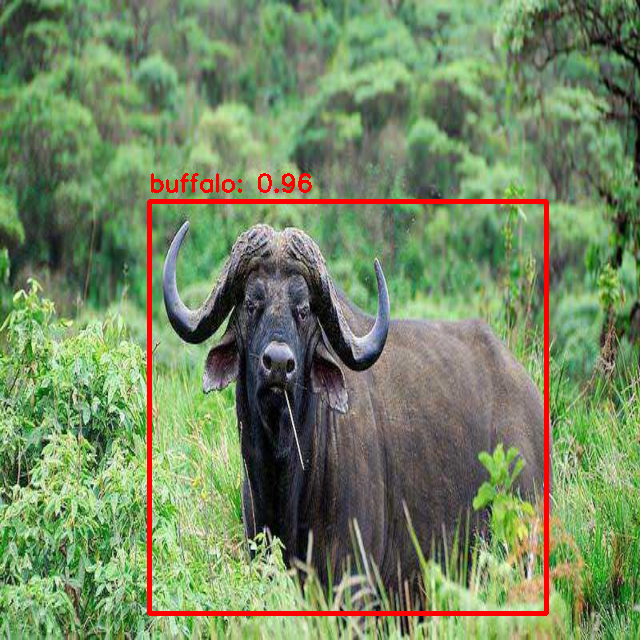

In [49]:
rcnn_model.eval()

image, target = val_dataset[0]

with torch.no_grad():
    prediction = rcnn_model([image.to(device)])[0]

show_rcnn_prediction(
    image_tensor=image,
    prediction=prediction,
    class_names=class_names,
    score_threshold=0.25
)